# 1. Mô tả bài toán

Mục tiêu của dự án là phân tích hành vi khách hàng từ bộ dữ liệu **Women's Clothing Reviews** và xây dựng mô hình học có giám sát để dự đoán liệu khách hàng có đề xuất một sản phẩm quần áo hay không.

Bài toán được xây dựng dưới dạng **phân loại nhị phân**.
**Đầu vào (Input):** Văn bản bình luận (`Title` + `Review Text`) mã hóa qua TF-IDF  
**Mục tiêu (Target):** `Recommended IND` (1: Khuyên mua / Tích cực, 0: Không khuyên mua / Tiêu cực)  

$$[
X = \text{các đặc trưng về đánh giá}
]$$

$$[
y = \text{Recommended IND}
]$$

Trong đó:

- `Recommended IND = 1`: khách hàng đề xuất sản phẩm.
- `Recommended IND = 0`: khách hàng không đề xuất sản phẩm.

Mô hình sẽ học các mẫu từ thông tin đánh giá của khách hàng, đặc điểm khách hàng và thông tin phân loại sản phẩm để dự đoán hành vi đề xuất sản phẩm.

# 2. Nguồn dữ liệu

| Nội dung | Thông tin |
|---|---|
| Tên bộ dữ liệu | Womens Clothing E-Commerce Reviews |
| Nguồn công khai | [Kaggle - Womens E-Commerce Clothing Reviews](https://www.kaggle.com/datasets/nicapotato/womens-ecommerce-clothing-reviews) |
| Nguồn gốc dữ liệu | Các review sản phẩm thời trang nữ trên nền tảng thương mại điện tử; metadata của bộ Kaggle không nêu tổ chức thu thập ban đầu |
| Tệp dùng trong dự án | Assigned_2/customer_behavior/Womens Clothing E-Commerce Reviews.csv |
| Miền bài toán | Thương mại điện tử; phân loại hành vi khuyến nghị sản phẩm từ review khách hàng |
| Giấy phép cần kiểm tra khi tái sử dụng | Theo điều khoản sử dụng của Kaggle và trang dataset gốc |

Bộ dữ liệu gồm **23.486 review sản phẩm**, với 11 cột gốc. Cột Unnamed: 0 chỉ là chỉ mục được lưu kèm CSV nên bị loại bỏ; dữ liệu còn **10 feature gốc** và một nhãn đầu ra là Recommended IND. Mỗi dòng là một review, bao gồm thông tin tuổi khách hàng, đánh giá sao, nội dung review, số lượt người đọc đánh giá review là hữu ích và phân loại sản phẩm.

Target Recommended IND là nhãn nhị phân: 1 nghĩa là khách hàng khuyến nghị sản phẩm, còn 0 nghĩa là không khuyến nghị. Cần lưu ý dataset không có Customer ID, vì vậy đây là dữ liệu ở cấp **review/sự kiện phản hồi**, không phải lịch sử giao dịch đầy đủ hay hồ sơ dài hạn của từng khách hàng.


# 3. Load dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# 6 Mô hình ML phân loại nhị phân
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Thiết lập hiển thị
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)


In [2]:
from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("Womens Clothing E-Commerce Reviews.csv")
TARGET_COLUMN = "Recommended IND"
df_raw = pd.read_csv(DATA_PATH)
df = df_raw.drop(columns="Unnamed: 0").copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended IND          23486 non-null  int64 
 6   Positive Feedback Count  23486 non-null  int64 
 7   Division Name            23472 non-null  object
 8   Department Name          23472 non-null  object
 9   Class Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.8+ MB


# 4. Mô tả dữ liệu

## 4.2. Ý nghĩa các đặc trưng

| Đặc trưng | Kiểu dữ liệu | Đơn vị/biểu diễn | Ý nghĩa |
|---|---|---|---|
| Clothing ID | Số nguyên | Mã định danh sản phẩm | Mã của sản phẩm được khách hàng review; có 1.206 giá trị riêng biệt. |
| Age | Số nguyên | Năm | Tuổi của khách hàng viết review. |
| Title | Văn bản | Chuỗi ký tự | Tiêu đề ngắn của review; có thể bị thiếu. |
| Review Text | Văn bản | Chuỗi ký tự | Nội dung review của khách hàng về sản phẩm; là nguồn input chính cho tokenizer hoặc TF-IDF sau này. |
| Rating | Số nguyên thứ bậc | 1 đến 5 sao | Mức độ đánh giá/hài lòng của khách hàng đối với sản phẩm. |
| Recommended IND | Nhị phân | 0 hoặc 1 | Nhãn mục tiêu cần dự đoán: 1 là khách hàng khuyến nghị sản phẩm, 0 là không khuyến nghị. |
| Positive Feedback Count | Số nguyên không âm | Số lượt bấm hữu ích | Số người đọc đánh giá review là hữu ích. |
| Division Name | Phân loại | 3 nhóm | Cấp phân loại sản phẩm rộng nhất, ví dụ General hoặc General Petite. |
| Department Name | Phân loại | 6 nhóm | Nhóm ngành hàng ở cấp trung gian, ví dụ Tops, Dresses hoặc Bottoms. |
| Class Name | Phân loại | 20 nhóm | Loại sản phẩm chi tiết nhất, ví dụ Dresses, Knits, Blouses hoặc Pants. |

Các cột Division Name, Department Name và Class Name có quan hệ phân cấp từ rộng đến chi tiết; Review Text là dữ liệu văn bản và chỉ được vector hóa sau khi chia train/test để tránh data leakage.

### 5. Tiền xử lý Dữ liệu & Xử lý Mất cân bằng Lớp (Data Preparation)

In [3]:
# 1. Loại bỏ các dòng trống Review Text
df = df_raw.dropna(subset=['Review Text']).copy()

# 2. Kết hợp Title và Review Text
df['Clean_Title'] = df['Title'].fillna('')
df['Full_Text'] = df['Clean_Title'] + ' ' + df['Review Text']

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['Clean_Text'] = df['Full_Text'].apply(clean_text)

# 3. Thống kê phân bố nhãn mục tiêu
rec_counts = df['Recommended IND'].value_counts()
print(f"Tổng số mẫu sau khi làm sạch: {len(df):,} mẫu")
print(f"  • Nhãn 1 (Khuyên mua / Tích cực)    : {rec_counts[1]:,} mẫu ({rec_counts[1]/len(df)*100:.1f}%)")
print(f"  • Nhãn 0 (Không khuyên / Tiêu cực) : {rec_counts[0]:,} mẫu ({rec_counts[0]/len(df)*100:.1f}%)")
print(f"  • Tỷ lệ mất cân bằng lớp: ~ 4.6 : 1 (Cần áp dụng class_weight='balanced')")

Tổng số mẫu sau khi làm sạch: 22,641 mẫu
  • Nhãn 1 (Khuyên mua / Tích cực)    : 18,540 mẫu (81.9%)
  • Nhãn 0 (Không khuyên / Tiêu cực) : 4,101 mẫu (18.1%)
  • Tỷ lệ mất cân bằng lớp: ~ 4.6 : 1 (Cần áp dụng class_weight='balanced')


class_weight='balanced'

Dataset có khoảng:

81.9% lớp 1
18.1% lớp 0

Nếu không xử lý mất cân bằng, model rất dễ thiên về lớp 1.

class_weight='balanced' khiến lỗi trên lớp thiểu số được coi trọng hơn.


### 6. Phân chia Train/Test & Biểu diễn Đặc trưng TF-IDF

In [4]:
# 1. Phân chia 80% Train - 20% Test (Stratified)
X_text = df['Clean_Text'].values
y = df['Recommended IND'].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_text, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 2. Trích xuất đặc trưng TF-IDF (N-gram 1-2, 3500 features)
tfidf_vec = TfidfVectorizer(
    max_features=3500,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True,
    norm='l2'
)

X_train = tfidf_vec.fit_transform(X_train_raw)
X_test = tfidf_vec.transform(X_test_raw)

print(f"✅ Ma trận Train (X_train): {X_train.shape[0]:,} mẫu x {X_train.shape[1]:,} đặc trưng")
print(f"✅ Ma trận Test  (X_test) : {X_test.shape[0]:,} mẫu x {X_test.shape[1]:,} đặc trưng")

✅ Ma trận Train (X_train): 18,112 mẫu x 3,500 đặc trưng
✅ Ma trận Test  (X_test) : 4,529 mẫu x 3,500 đặc trưng


## Customer Representation

Trong bài toán này, mỗi mẫu dữ liệu tương ứng với một đánh giá của khách hàng. Thông tin văn bản được sử dụng để biểu diễn hành vi khách hàng gồm hai trường:

- `Title`: tiêu đề của đánh giá.
- `Review Text`: nội dung chi tiết của đánh giá.

Hai trường này được kết hợp lại để tạo thành một văn bản hoàn chỉnh trước khi chuyển đổi sang dạng số.

### Bước 1. Kết hợp Title và Review Text

Các giá trị thiếu trong `Title` được thay bằng chuỗi rỗng, sau đó `Title` và `Review Text` được nối lại:

$$[
\text{Full\_Text} = \text{Title} + \text{Review Text}
]$$

Ví dụ:

**Title:**

`Flattering shirt`

**Review Text:**

`This shirt is very flattering to all due to the cut...`

Sau khi kết hợp:

`Flattering shirt This shirt is very flattering to all due to the cut...`

---

### Bước 2. Tiền xử lý văn bản

`Full_Text` được làm sạch để tạo thành `Clean_Text`.

Quá trình tiền xử lý bao gồm:

- Chuyển toàn bộ văn bản về chữ thường.
- Loại bỏ các ký tự không phải chữ cái.
- Loại bỏ khoảng trắng dư thừa.

Ví dụ:

`Flattering shirt! This shirt is very flattering.`

được chuyển thành:

`flattering shirt this shirt is very flattering`

---

### Bước 3. Tạo đặc trưng Unigram và Bigram

Sau khi làm sạch, văn bản được đưa vào `TfidfVectorizer` với:

`ngram_range=(1, 2)`

Do đó, hệ thống sử dụng cả:

- **Unigram**: một từ riêng lẻ, ví dụ `shirt`, `flattering`.
- **Bigram**: hai từ liên tiếp, ví dụ `flattering shirt`, `very flattering`.

`TfidfVectorizer` xây dựng một vocabulary chung từ tập huấn luyện.

Trong bài này:

`max_features=3500`

nên tối đa **3500 từ hoặc cụm từ** được giữ lại làm đặc trưng.

---
### Bước 4. Tính TF-IDF và chuyển văn bản thành vector số

Sau khi xây dựng vocabulary, mỗi từ hoặc cụm từ trong vocabulary sẽ tương ứng với một vị trí cố định trong vector đặc trưng.

TF-IDF được tính từ hai thành phần chính là **TF (Term Frequency)** và **IDF (Inverse Document Frequency)**.

#### 4.1. Tính TF - Term Frequency

TF thể hiện mức độ xuất hiện của một từ hoặc cụm từ trong một văn bản cụ thể.

Công thức cơ bản:

$$
TF(t,d)=\frac{\text{số lần từ }t\text{ xuất hiện trong văn bản }d}{\text{tổng số từ trong văn bản }d}
$$

Ví dụ với văn bản:

`dress dress comfortable`

Ta có:

$$
TF(\text{dress})=\frac{2}{3}
$$

$$
TF(\text{comfortable})=\frac{1}{3}
$$

Trong bài này, `TfidfVectorizer` sử dụng:

`sublinear_tf=True`

nên tần suất từ được biến đổi theo logarit:

$$
TF(t,d)=1+\log(tf)
$$

Cách này giúp giảm ảnh hưởng của những từ xuất hiện lặp lại quá nhiều trong cùng một review.

---

#### 4.2. Tính IDF - Inverse Document Frequency

IDF thể hiện mức độ hiếm của một từ hoặc cụm từ trong toàn bộ tập huấn luyện.

Nếu một từ xuất hiện trong rất nhiều review thì từ đó có khả năng phân biệt thấp và IDF sẽ nhỏ.

Ngược lại, nếu một từ chỉ xuất hiện trong một số ít review thì IDF sẽ lớn hơn.

Công thức cơ bản:

$$
IDF(t)=\log\left(\frac{N}{df(t)}\right)
$$

Trong đó:

- $N$: tổng số văn bản trong tập huấn luyện.
- $df(t)$: số văn bản có chứa từ hoặc cụm từ $t$.

Trong `TfidfVectorizer`, IDF được tính với smoothing:

$$
IDF(t)=\log\left(\frac{1+N}{1+df(t)}\right)+1
$$

Ví dụ:

- `dress` xuất hiện trong rất nhiều review nên có IDF tương đối thấp.
- `poor quality` chỉ xuất hiện trong một số review nên có thể có IDF cao hơn.

---

#### 4.3. Tính trọng số TF-IDF

Trọng số TF-IDF của một từ hoặc cụm từ được tính bằng:

$$
TFIDF(t,d)=TF(t,d)\times IDF(t)
$$

Một đặc trưng sẽ có trọng số TF-IDF cao khi:

- xuất hiện nhiều trong review hiện tại;
- nhưng không xuất hiện quá phổ biến trong toàn bộ tập dữ liệu.

Do đó, TF-IDF giúp làm nổi bật những từ hoặc cụm từ có tính đặc trưng cao cho từng review.

---

#### 4.4. Biểu diễn mỗi review thành vector

Giả sử vocabulary được xây dựng như sau:

$$
V=
[\text{comfortable},\text{dress},\text{flattering shirt},\text{love},\text{poor quality}]
$$

Mỗi từ hoặc cụm từ sẽ tương ứng với một vị trí cố định:

$$
0 \rightarrow \text{comfortable}
$$

$$
1 \rightarrow \text{dress}
$$

$$
2 \rightarrow \text{flattering shirt}
$$

$$
3 \rightarrow \text{love}
$$

$$
4 \rightarrow \text{poor quality}
$$

Sau khi tính TF-IDF, một review có thể được biểu diễn thành:

$$
x_i=[0,\ 0.32,\ 0.61,\ 0,\ 0]
$$

Trong đó:

- `0.32` là trọng số TF-IDF của từ `dress`.
- `0.61` là trọng số TF-IDF của cụm `flattering shirt`.
- Giá trị `0` nghĩa là đặc trưng đó không xuất hiện trong review.

Trong bài toán thực tế, vocabulary có tối đa 3500 đặc trưng nên mỗi review được biểu diễn bởi:

$$
x_i=[w_1,w_2,\ldots,w_{3500}]
$$

Trong đó $w_j$ là trọng số TF-IDF của từ hoặc cụm từ thứ $j$ trong vocabulary.

Cuối cùng, các vector của tất cả review được ghép lại thành ma trận đặc trưng và đưa vào mô hình học máy:

$$
\text{Title + Review Text}
\rightarrow
\text{Clean Text}
\rightarrow
\text{Unigram / Bigram}
\rightarrow
\text{Vocabulary}
\rightarrow
\text{TF}
\rightarrow
\text{IDF}
\rightarrow
\text{TF-IDF Vector}
\rightarrow
\text{Machine Learning Model}
$$

---

### Bước 5. Tạo ma trận đặc trưng

Sau khi tất cả các mẫu được chuyển thành vector TF-IDF, các vector được ghép thành ma trận đặc trưng.

Tập huấn luyện có kích thước:

$$[
X_{train} \in \mathbb{R}^{18112 \times 3500}
]$$

Tập kiểm tra có kích thước:

$$[
X_{test} \in \mathbb{R}^{4529 \times 3500}
]$$

Trong đó:

- Mỗi **hàng** tương ứng với một đánh giá của khách hàng.
- Mỗi **cột** tương ứng với một unigram hoặc bigram trong vocabulary.
- Mỗi ô chứa trọng số TF-IDF của đặc trưng đó trong đánh giá tương ứng.

---

### Bước 6. Đưa vector vào mô hình

Vector TF-IDF của mỗi mẫu được sử dụng làm đầu vào cho mô hình học máy:

$$[
x_i = [w_1,w_2,...,w_{3500}]
]$$

Target tương ứng là:

$$[
y_i \in \{0,1\}
]$$

Trong đó:

- $$(y_i = 1)$$: khách hàng đề xuất sản phẩm.
- $$(y_i = 0)$$: khách hàng không đề xuất sản phẩm.

Mô hình học mối quan hệ:

$$[
f(x_i) \rightarrow y_i
]$$




### 7. Huấn luyện & Đánh giá So sánh 6 Mô hình Máy học

Mỗi review sau TF-IDF trở thành vector:

$$ x_i=[x_{i1},x_{i2},...,x_{i3500}] $$

trong đó mỗi $x_{ij}$ là trọng số TF-IDF của unigram/bigram thứ $j$.

Target:

$$ y_i\in\{0,1\} $$
$y=1$: khách hàng recommend sản phẩm.
$y=0$: khách hàng không recommend.

Như vậy cả 6 model đều nhận cùng một ma trận TF-IDF, nhưng cách chúng học từ 3500 giá trị này hoàn toàn khác nhau.

## 7.1. Logistic Regression

Logistic Regression là mô hình phân loại tuyến tính. Với mỗi review sau khi được biểu diễn bằng TF-IDF, ta có vector:

$$
x_i=[x_{i1},x_{i2},...,x_{i3500}]
$$

Trong đó mỗi $x_{ij}$ là trọng số TF-IDF của unigram hoặc bigram thứ $j$.

Logistic Regression gán cho mỗi đặc trưng một trọng số:

$$
w=[w_1,w_2,...,w_{3500}]
$$

và tính một giá trị tuyến tính:

$$
z=w^Tx+b
$$

hay:

$$
z=w_1x_1+w_2x_2+...+w_{3500}x_{3500}+b
$$

Sau đó, giá trị $z$ được đưa qua hàm sigmoid:

$$
P(y=1|x)=\sigma(z)=\frac{1}{1+e^{-z}}
$$

Kết quả nằm trong khoảng:

$$
0 \le P(y=1|x) \le 1
$$

Trong bài toán này:

- $y=1$: khách hàng đề xuất sản phẩm.
- $y=0$: khách hàng không đề xuất sản phẩm.

Thông thường, nếu:

$$
P(y=1|x)\ge0.5
$$

thì dự đoán:

$$
\hat y=1
$$

ngược lại:

$$
\hat y=0
$$

### Hàm mất mát

Logistic Regression học các trọng số $w$ bằng cách tối thiểu hóa Binary Cross-Entropy:

$$
L=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Trong đó:

- $y_i$: nhãn thật.
- $p_i$: xác suất model dự đoán mẫu thuộc lớp 1.

Nếu model dự đoán sai nhưng rất tự tin, loss sẽ lớn.

### Regularization

Trong mô hình sử dụng:

`C=1.0`

Logistic Regression áp dụng regularization để hạn chế trọng số quá lớn và giảm overfitting.

Về ý tưởng:

$$
J(w)=Loss+\lambda||w||_2^2
$$

Trong đó:

$$
||w||_2^2=w_1^2+w_2^2+...+w_{3500}^2
$$

Tham số $C$ có quan hệ nghịch với mức regularization:

$$
C\propto\frac{1}{\lambda}
$$

- $C$ lớn: regularization yếu hơn.
- $C$ nhỏ: regularization mạnh hơn.

### Ý nghĩa với dữ liệu TF-IDF

Mỗi trọng số $w_j$ thể hiện ảnh hưởng của một từ hoặc cụm từ đối với kết quả dự đoán.

Ví dụ:

$$
w_{\text{love}}>0
$$

có thể làm xác suất recommend tăng.

Ngược lại:

$$
w_{\text{poor quality}}<0
$$

có thể làm xác suất recommend giảm.

Do đó, Logistic Regression đặc biệt phù hợp với dữ liệu TF-IDF có số chiều lớn và dễ giải thích.
## 7.2. Linear Support Vector Machine

Linear SVM là mô hình phân loại tuyến tính có mục tiêu tìm một siêu phẳng để phân chia hai lớp.

Với đầu vào TF-IDF:

$$
x_i\in\mathbb{R}^{3500}
$$

SVM xây dựng hàm:

$$
f(x)=w^Tx+b
$$

Siêu phẳng phân chia hai lớp là:

$$
w^Tx+b=0
$$

Dự đoán được xác định dựa trên dấu của $f(x)$:

$$
\hat y=
\begin{cases}
1,&f(x)>0\\
0,&f(x)<0
\end{cases}
$$

### Margin

SVM không chỉ tìm một siêu phẳng phân loại đúng mà còn cố gắng tạo khoảng cách lớn nhất giữa hai lớp.

Độ rộng margin là:

$$
\frac{2}{||w||}
$$

Do đó, muốn margin lớn thì cần làm nhỏ:

$$
||w||
$$

### Điều kiện phân loại

Trong lý thuyết SVM, nhãn thường được biểu diễn:

$$
y_i\in\{-1,+1\}
$$

Mô hình mong muốn:

$$
y_i(w^Tx_i+b)\ge1
$$

Nếu:

$$
y_i(w^Tx_i+b)\ge1
$$

thì mẫu được phân loại đúng và nằm ngoài margin.

Nếu:

$$
0<y_i(w^Tx_i+b)<1
$$

thì mẫu được phân loại đúng nhưng nằm trong margin.

Nếu:

$$
y_i(w^Tx_i+b)<0
$$

thì mẫu bị phân loại sai.

### Hàm mất mát

Hinge Loss cơ bản:

$$
L_i=\max(0,1-y_if(x_i))
$$

Trong `LinearSVC`, mặc định sử dụng Squared Hinge Loss:

$$
L_i=
\max(0,1-y_if(x_i))^2
$$

Hàm mục tiêu có dạng:

$$
\min_{w,b}
\frac{1}{2}||w||^2
+
C\sum_{i=1}^{N}L_i
$$

Trong đó:

- $\frac{1}{2}||w||^2$: khuyến khích margin lớn.
- $\sum L_i$: phạt các mẫu vi phạm margin hoặc phân loại sai.
- $C$: điều chỉnh mức cân bằng giữa margin và lỗi training.

### Ý nghĩa của C

Với:

`C=1.0`

- $C$ lớn: phạt lỗi mạnh hơn, model cố phân loại training đúng hơn.
- $C$ nhỏ: chấp nhận nhiều lỗi hơn để có margin rộng hơn.

### Liên hệ với TF-IDF

Mỗi review là một điểm trong không gian 3500 chiều.

Linear SVM tìm một hyperplane:

$$
w^Tx+b=0
$$

để tách các review thuộc hai lớp `Recommended IND = 0` và `Recommended IND = 1`.

Linear SVM thường hoạt động tốt với dữ liệu văn bản TF-IDF vì dữ liệu có số chiều lớn và có tính sparse.

## 7.3. Multinomial Naive Bayes

Multinomial Naive Bayes là mô hình phân loại dựa trên định lý Bayes.

Theo định lý Bayes:

$$
P(y|x)=\frac{P(x|y)P(y)}{P(x)}
$$

Khi so sánh giữa các lớp, $P(x)$ là như nhau nên có thể viết:

$$
P(y|x)\propto P(x|y)P(y)
$$

Trong bài toán này, model cần so sánh:

$$
P(y=1|x)
$$

và:

$$
P(y=0|x)
$$

sau đó chọn lớp có xác suất lớn hơn.

### Xác suất tiên nghiệm

Model đầu tiên học xác suất xuất hiện của từng lớp:

$$
P(y=1)=\frac{N_1}{N}
$$

$$
P(y=0)=\frac{N_0}{N}
$$

Trong đó:

- $N_1$: số mẫu thuộc lớp 1.
- $N_0$: số mẫu thuộc lớp 0.
- $N$: tổng số mẫu.

### Xác suất có điều kiện

Model tiếp tục học xác suất một feature xuất hiện trong từng lớp.

Ví dụ:

$$
P(\text{love}|y=1)
$$

$$
P(\text{love}|y=0)
$$

Nếu từ `love` xuất hiện nhiều hơn trong các review recommend thì có thể:

$$
P(\text{love}|y=1)>
P(\text{love}|y=0)
$$

Ngược lại, với cụm `poor quality` có thể:

$$
P(\text{poor quality}|y=0)>
P(\text{poor quality}|y=1)
$$

### Giả định Naive

Naive Bayes giả định các feature độc lập có điều kiện khi đã biết class:

$$
P(x_1,x_2,...,x_m|y)
=
\prod_{j=1}^{m}P(x_j|y)
$$

Trong bài này:

$$
m=3500
$$

Mặc dù các từ trong ngôn ngữ thực tế không hoàn toàn độc lập, giả định này vẫn hoạt động tốt trong nhiều bài toán phân loại văn bản.

### Công thức Multinomial Naive Bayes

Với một lớp $c$:

$$
P(c|x)
\propto
P(c)
\prod_{j=1}^{m}
P(t_j|c)^{x_j}
$$

Để tránh nhân nhiều số rất nhỏ, model sử dụng log:

$$
\log P(c|x)
\propto
\log P(c)
+
\sum_{j=1}^{3500}
x_j\log P(t_j|c)
$$

Model chọn lớp:

$$
\hat y=
\arg\max_c
\left[
\log P(c)
+
\sum_jx_j\log P(t_j|c)
\right]
$$

### Laplace/Additive Smoothing

Trong bài sử dụng:

`alpha=0.1`

Nếu một feature chưa từng xuất hiện trong một class thì xác suất có thể bằng 0.

Để tránh điều này, model sử dụng smoothing:

$$
P(t_j|c)
=
\frac{N_{jc}+\alpha}
{N_c+\alpha V}
$$

Trong đó:

- $N_{jc}$: tổng giá trị feature $j$ trong class $c$.
- $N_c$: tổng giá trị các feature trong class $c$.
- $V$: số feature.
- $\alpha$: hệ số smoothing.

Multinomial Naive Bayes đặc biệt phù hợp với dữ liệu text vì các feature đều không âm và biểu diễn mức độ xuất hiện của từ hoặc cụm từ.

## 7.4. SGD Classifier

SGD Classifier là mô hình tuyến tính được huấn luyện bằng thuật toán **Stochastic Gradient Descent**.

Trong bài này sử dụng:

`loss='log_loss'`

nên mô hình có bản chất gần giống Logistic Regression.

Model tính:

$$
z=w^Tx+b
$$

sau đó:

$$
P(y=1|x)
=
\frac{1}{1+e^{-z}}
$$

### Logistic Loss

Mô hình tối ưu hàm mất mát:

$$
L_i=
-\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

Trong đó:

$$
p_i=\sigma(w^Tx_i+b)
$$

### Gradient Descent

Nếu sử dụng toàn bộ dữ liệu để cập nhật trọng số, ta có:

$$
w
\leftarrow
w-\eta\nabla J(w)
$$

Trong đó:

- $\eta$: learning rate.
- $\nabla J(w)$: gradient của hàm loss.

### Stochastic Gradient Descent

SGD không cần sử dụng toàn bộ tập dữ liệu trong mỗi lần cập nhật.

Nó có thể cập nhật trọng số theo từng mẫu:

$$
w
\leftarrow
w-\eta\nabla L_i(w)
$$

Đối với logistic loss:

$$
\nabla_wL_i
=
(p_i-y_i)x_i
$$

Do đó:

$$
w
\leftarrow
w-\eta(p_i-y_i)x_i
$$

Nếu model dự đoán sai nhiều thì:

$$
|p_i-y_i|
$$

sẽ lớn và trọng số được điều chỉnh mạnh.

Nếu dự đoán gần đúng thì trọng số chỉ thay đổi ít.

### Epoch

Một lần model đi qua toàn bộ tập huấn luyện được gọi là một epoch.

Với:

`max_iter=1000`

model được phép thực hiện tối đa 1000 vòng lặp tối ưu.

### Ưu điểm với TF-IDF

Dữ liệu TF-IDF là sparse, nghĩa là phần lớn các phần tử trong vector bằng 0.

Ví dụ:

$$
x_i=[0,0,0.41,0,...,0.62,...]
$$

SGD có thể xử lý loại dữ liệu này rất hiệu quả và có tốc độ huấn luyện nhanh.

Do đó, SGD Classifier phù hợp với bài toán phân loại văn bản có số lượng mẫu lớn và số chiều cao.

## 7.5. Decision Tree

Decision Tree là mô hình phân loại dựa trên một chuỗi các luật điều kiện.

Khác với Logistic Regression hay SVM, Decision Tree không xây dựng hàm:

$$
w^Tx+b
$$

mà liên tục chia dữ liệu dựa trên các feature.

Ví dụ:

`TF-IDF("love") > 0.2`

hoặc:

`TF-IDF("poor quality") > 0.1`

Mỗi phép chia tạo ra các node con.

### Gini Impurity

Trong `DecisionTreeClassifier`, tiêu chí mặc định là Gini Impurity:

$$
Gini
=
1-\sum_{k=1}^{K}p_k^2
$$

Trong bài toán nhị phân:

$$
Gini
=
1-(p_0^2+p_1^2)
$$

Trong đó:

- $p_0$: tỷ lệ mẫu lớp 0 trong node.
- $p_1$: tỷ lệ mẫu lớp 1 trong node.

Nếu node có:

$$
p_0=0.5,\quad p_1=0.5
$$

thì:

$$
Gini
=
1-(0.5^2+0.5^2)
=
0.5
$$

Node còn rất hỗn tạp.

Nếu tất cả mẫu thuộc cùng một lớp:

$$
Gini=0
$$

Node hoàn toàn thuần khiết.

### Lựa chọn phép chia

Giả sử một node được chia thành hai node con Left và Right.

Gini sau khi chia là:

$$
Gini_{split}
=
\frac{N_L}{N}Gini_L
+
\frac{N_R}{N}Gini_R
$$

Mức giảm impurity:

$$
\Delta Gini
=
Gini_{parent}
-
Gini_{split}
$$

Decision Tree tìm feature và threshold làm cho:

$$
\Delta Gini
$$

lớn nhất.

### Độ sâu của cây

Trong bài sử dụng:

`max_depth=25`

Điều này giới hạn số mức tối đa của cây nhằm giảm overfitting.

Nếu không giới hạn độ sâu, cây có thể tiếp tục chia cho đến khi gần như ghi nhớ dữ liệu training.

### Liên hệ với TF-IDF

Decision Tree có thể học các rule như:

`TF-IDF("poor quality") > 0.15`

sau đó tiếp tục xét feature khác.

Tuy nhiên, TF-IDF có tới 3500 feature và phần lớn giá trị bằng 0. Do đó, một Decision Tree đơn có thể tạo ra nhiều rule quá cụ thể và dễ overfit.

Đây là một lý do Decision Tree thường không mạnh bằng các mô hình tuyến tính trong bài toán phân loại văn bản.

## 7.6. Random Forest

Random Forest là mô hình ensemble kết hợp nhiều Decision Tree.

Thay vì chỉ sử dụng một cây:

$$
T_1
$$

Random Forest sử dụng:

$$
T_1,T_2,...,T_B
$$

Trong bài:

$$
B=150
$$

do sử dụng:

`n_estimators=150`

### Bootstrap Sampling

Mỗi Decision Tree được huấn luyện trên một tập dữ liệu bootstrap khác nhau.

Từ tập huấn luyện ban đầu:

$$
D=\{x_1,x_2,...,x_N\}
$$

Random Forest tạo các tập:

$$
D_1,D_2,...,D_B
$$

bằng cách lấy mẫu có hoàn lại.

Do đó, các cây không hoàn toàn giống nhau.

### Random Feature Selection

Tại mỗi node, Random Forest không xét toàn bộ 3500 feature.

Với classification, mặc định:

`max_features='sqrt'`

Do đó số feature được xem xét tại mỗi split xấp xỉ:

$$
\sqrt{3500}\approx59
$$

Việc chỉ xét một tập con ngẫu nhiên các feature giúp các cây khác nhau hơn và giảm tương quan giữa chúng.

### Mỗi cây vẫn sử dụng Decision Tree

Từng cây sử dụng Gini Impurity:

$$
Gini
=
1-\sum_{k=1}^{K}p_k^2
$$

và tìm phép chia làm giảm impurity nhiều nhất.

Trong bài:

`max_depth=25`

nên mỗi cây có độ sâu tối đa là 25.

### Tổng hợp dự đoán

Giả sử có $B$ cây:

$$
T_1(x),T_2(x),...,T_B(x)
$$

Mỗi cây đưa ra xác suất của từng class.

Random Forest lấy trung bình các xác suất:

$$
P(y=c|x)
=
\frac{1}{B}
\sum_{b=1}^{B}P_b(y=c|x)
$$

Sau đó chọn class có xác suất trung bình lớn nhất:

$$
\hat y
=
\arg\max_c P(y=c|x)
$$

### Tại sao Random Forest tốt hơn một Decision Tree?

Decision Tree đơn thường có variance cao và dễ overfit.

Random Forest kết hợp nhiều cây:

$$
\hat f(x)
=
\frac{1}{B}
\sum_{b=1}^{B}f_b(x)
$$

nên giảm variance và tăng khả năng tổng quát hóa.

Trong bài toán này, Random Forest có thể cải thiện đáng kể so với Decision Tree đơn, tuy nhiên vẫn có thể kém các mô hình tuyến tính vì dữ liệu TF-IDF có số chiều lớn và rất sparse.

In [5]:
models = {
    "Logistic Regression (Balanced)": LogisticRegression(class_weight='balanced', max_iter=1000, C=1.0, random_state=42),
    "Linear SVM (Balanced)": LinearSVC(class_weight='balanced', C=1.0, random_state=42, max_iter=2000),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "SGD Classifier (Balanced Log)": SGDClassifier(loss='log_loss', class_weight='balanced', max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=25, class_weight='balanced', random_state=42),
    "Random Forest (Balanced)": RandomForestClassifier(n_estimators=150, max_depth=25, class_weight='balanced', n_jobs=-1, random_state=42)
}

results_list = []
roc_curves_data = {}

for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    y_pred = model.predict(X_test)
    
    # Tính xác suất hoặc decision function để vẽ ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
    else:
        y_prob = y_pred
        
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_curves_data[name] = (fpr, tpr, roc_auc)
    
    results_list.append({
        "Model": name,
        "Accuracy (%)": round(acc * 100, 2),
        "Precision (%)": round(prec * 100, 2),
        "Recall (%)": round(rec * 100, 2),
        "F1-Score (%)": round(f1 * 100, 2),
        "ROC-AUC": round(roc_auc, 4),
        "Training Time (s)": round(train_time, 3)
    })

df_results = pd.DataFrame(results_list).sort_values(by='F1-Score (%)', ascending=False)
print("=== BẢNG SO SÁNH HIỆU NĂNG 6 MÔ HÌNH DỰ ĐOÁN HÀNH VI KHUYẾN NGHỊ (RECOMMENDED IND) ===")
df_results

=== BẢNG SO SÁNH HIỆU NĂNG 6 MÔ HÌNH DỰ ĐOÁN HÀNH VI KHUYẾN NGHỊ (RECOMMENDED IND) ===


,Model,Accuracy (%),Precision (%),Recall (%),F1-Score (%),ROC-AUC,Training Time (s)
2,Multinomial Naive Bayes,88.05,89.40,96.90,93.00,0.9322,0.008
5,Random Forest (Balanced),87.57,93.53,91.13,92.31,0.9091,1.714
0,Logistic Regression (Balanced),87.88,96.31,88.60,92.29,0.9403,0.108
3,SGD Classifier (Balanced Log),87.75,96.41,88.33,92.19,0.9402,0.075
1,Linear SVM (Balanced),86.97,94.70,89.08,91.80,0.9233,0.142
4,Decision Tree,78.01,91.09,81.07,85.79,0.7038,5.297


Bảng được sắp xếp theo F1-score giảm dần, nên theo tiêu chí mà notebook đang đặt ra, Multinomial Naive Bayes đứng đầu với F1-score 93.00% và Recall 96.90%. Model này đặc biệt ít bỏ sót lớp 1 — review khuyến nghị. Đồng thời, thời gian train chỉ 0.007 giây, nhanh nhất trong sáu model.  
Logistic Regression (Balanced) có Accuracy cao nhất, 87.88%, và ROC-AUC cao nhất, 0.9403. SGD Classifier (Balanced Log) có ROC-AUC gần như tương đương, 0.9402, nhưng train nhanh hơn. Random Forest cũng có kết quả tốt, nhưng thời gian train 1.705 giây cao hơn nhiều so với các model tuyến tính và Naive Bayes.  
Decision Tree có kết quả kém nhất: F1-score 85.79%, Recall 81.07% và ROC-AUC 0.7038, trong khi train lâu nhất, 4.947 giây. Điều này cho thấy một cây quyết định đơn lẻ không phù hợp với ma trận TF-IDF 3.500 chiều, vốn thưa và có số feature lớn.

## 8. Trực quan hóa So sánh Hiệu năng & Đường cong ROC (ROC Curves)

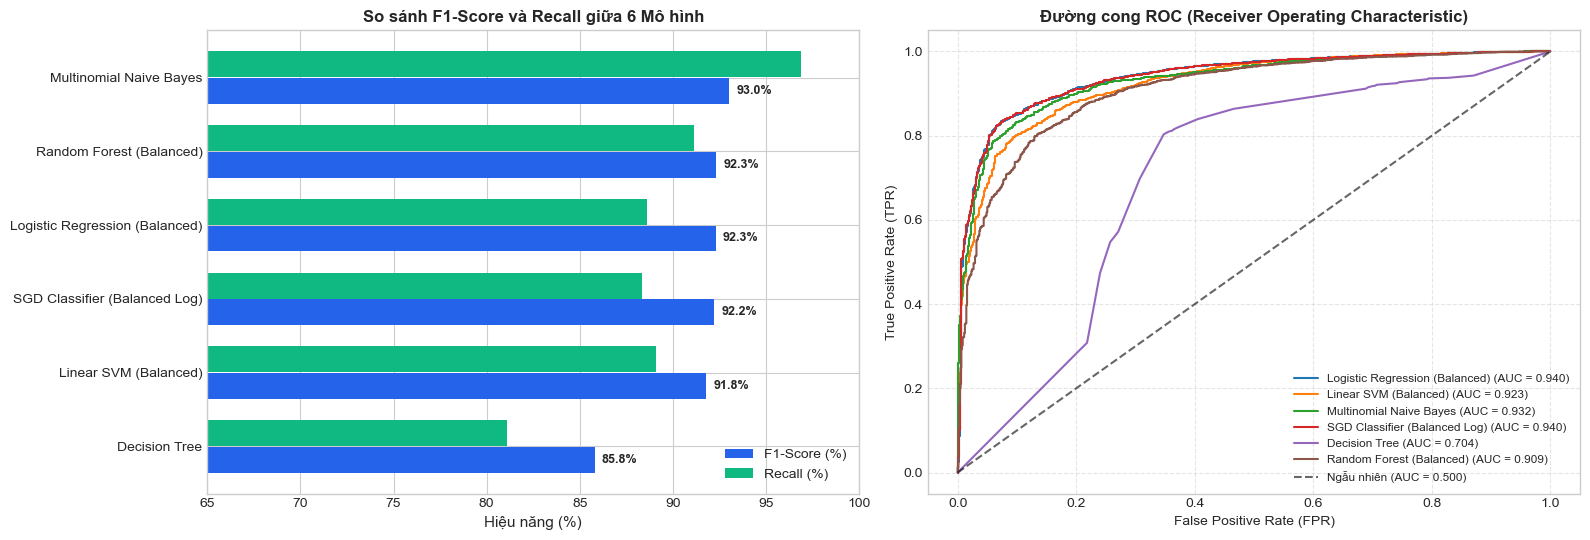

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

# 1. Biểu đồ F1-Score & Recall
df_plot = df_results.sort_values(by='F1-Score (%)', ascending=True)
y_pos = np.arange(len(df_plot))

axes[0].barh(y_pos - 0.18, df_plot['F1-Score (%)'], height=0.35, label='F1-Score (%)', color='#2563eb')
axes[0].barh(y_pos + 0.18, df_plot['Recall (%)'], height=0.35, label='Recall (%)', color='#10b981')
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(df_plot['Model'], fontsize=10)
axes[0].set_xlabel('Hiệu năng (%)', fontsize=11)
axes[0].set_title('So sánh F1-Score và Recall giữa 6 Mô hình', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].set_xlim(65, 100)
for i, v in enumerate(df_plot['F1-Score (%)']):
    axes[0].text(v + 0.4, i - 0.18, f"{v:.1f}%", va='center', fontsize=9, fontweight='bold')

# 2. Đường cong ROC Curves
for name, (fpr, tpr, auc_val) in roc_curves_data.items():
    axes[1].plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.3f})', linewidth=1.5)

axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.6, label='Ngẫu nhiên (AUC = 0.500)')
axes[1].set_title('Đường cong ROC (Receiver Operating Characteristic)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('False Positive Rate (FPR)')
axes[1].set_ylabel('True Positive Rate (TPR)')
axes[1].legend(loc='lower right', fontsize=8.5)
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Trên đồ thị ROC, Logistic Regression có AUC cao nhất (0.940), gần như bằng SGD Classifier (0.940), và cao hơn Naive Bayes (0.932). Điều này cho thấy Logistic Regression có khả năng phân tách tổng thể hai lớp tốt nhất khi thay đổi ngưỡng dự đoán.  
Decision Tree thấp hơn rõ rệt: F1-score 85.8%, Recall 81.1%, AUC 0.704; đường ROC của model này gần đường ngẫu nhiên hơn các model khác. Đây là model kém phù hợp nhất với dữ liệu review đã TF-IDF.  
Các đường ROC của Logistic Regression, SGD, Naive Bayes và Random Forest đều nằm xa phía trên-trái và khá sát nhau, cho thấy chúng đều hiệu quả

## 9. Đánh giá Chi tiết Mô hình Tốt nhất (Logistic Regression) & Confusion Matrix

=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===
                  precision    recall  f1-score   support

Không khuyên (0)       0.62      0.85      0.72       820
  Khuyên mua (1)       0.96      0.89      0.92      3709

        accuracy                           0.88      4529
       macro avg       0.79      0.87      0.82      4529
    weighted avg       0.90      0.88      0.89      4529



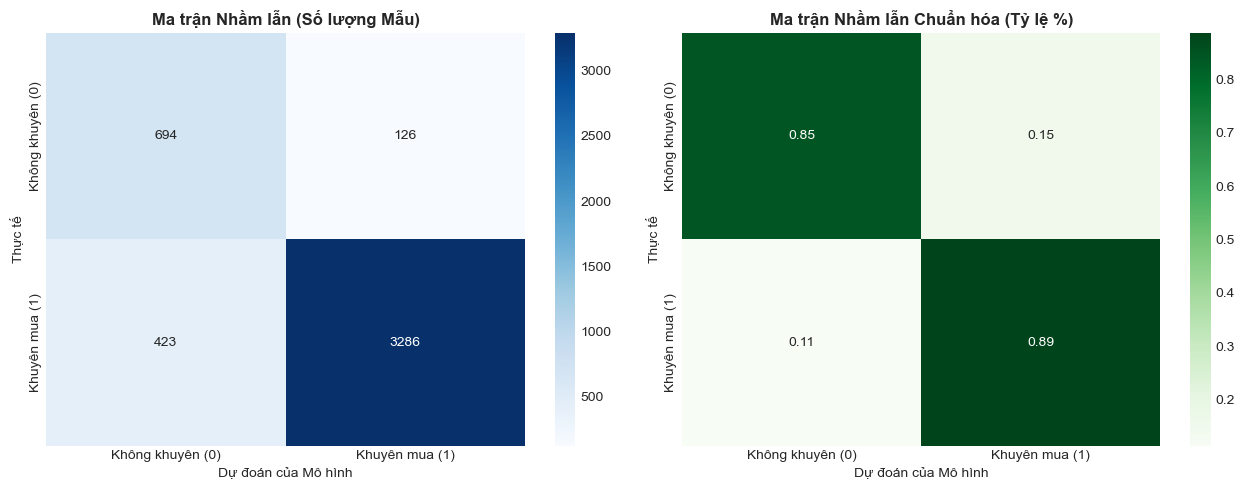

In [7]:
best_model = models["Logistic Regression (Balanced)"]
y_pred_best = best_model.predict(X_test)

print("=== BÁO CÁO PHÂN LOẠI CHI TIẾT (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred_best, target_names=['Không khuyên (0)', 'Khuyên mua (1)']))

# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Không khuyên (0)', 'Khuyên mua (1)'],
            yticklabels=['Không khuyên (0)', 'Khuyên mua (1)'])
axes[0].set_title('Ma trận Nhầm lẫn (Số lượng Mẫu)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dự đoán của Mô hình')
axes[0].set_ylabel('Thực tế')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens', ax=axes[1],
            xticklabels=['Không khuyên (0)', 'Khuyên mua (1)'],
            yticklabels=['Không khuyên (0)', 'Khuyên mua (1)'])
axes[1].set_title('Ma trận Nhầm lẫn Chuẩn hóa (Tỷ lệ %)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dự đoán của Mô hình')
axes[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

Với Logistic Regression (Balanced), trong 820 review thực tế không khuyến nghị (lớp 0), model dự đoán đúng 694 review và dự đoán nhầm 126 review thành khuyến nghị. Như vậy, Recall của lớp 0 là khoảng 84.6%; model phát hiện được phần lớn review tiêu cực, nhưng vẫn bỏ sót 15.4%.  
Trong 3.709 review thực tế khuyến nghị (lớp 1), model dự đoán đúng 3.286 review và dự đoán nhầm 423 review là không khuyến nghị. Recall lớp 1 đạt khoảng 88.6%, phù hợp với bảng metric trước đó.  
class_weight="balanced" có tác dụng rõ: mặc dù lớp 0 ít hơn nhiều, model vẫn nhận diện đúng 694/820 review không khuyến nghị. Nếu không cân bằng trọng số, model có thể thiên về dự đoán lớp 1 và Recall lớp 0 có thể thấp hơn.  
Tuy nhiên, có 126 review thực tế không khuyến nghị nhưng bị dự đoán là khuyến nghị. Trong ứng dụng thực tế, đây là nhóm cần chú ý vì hệ thống có thể bỏ qua trải nghiệm tiêu cực của khách hàng. Tổng thể, Logistic Regression cân bằng tương đối tốt giữa hai lớp

### 10. Phân tích Trọng số Đặc trưng: Top Từ khóa Tích cực vs Tiêu cực

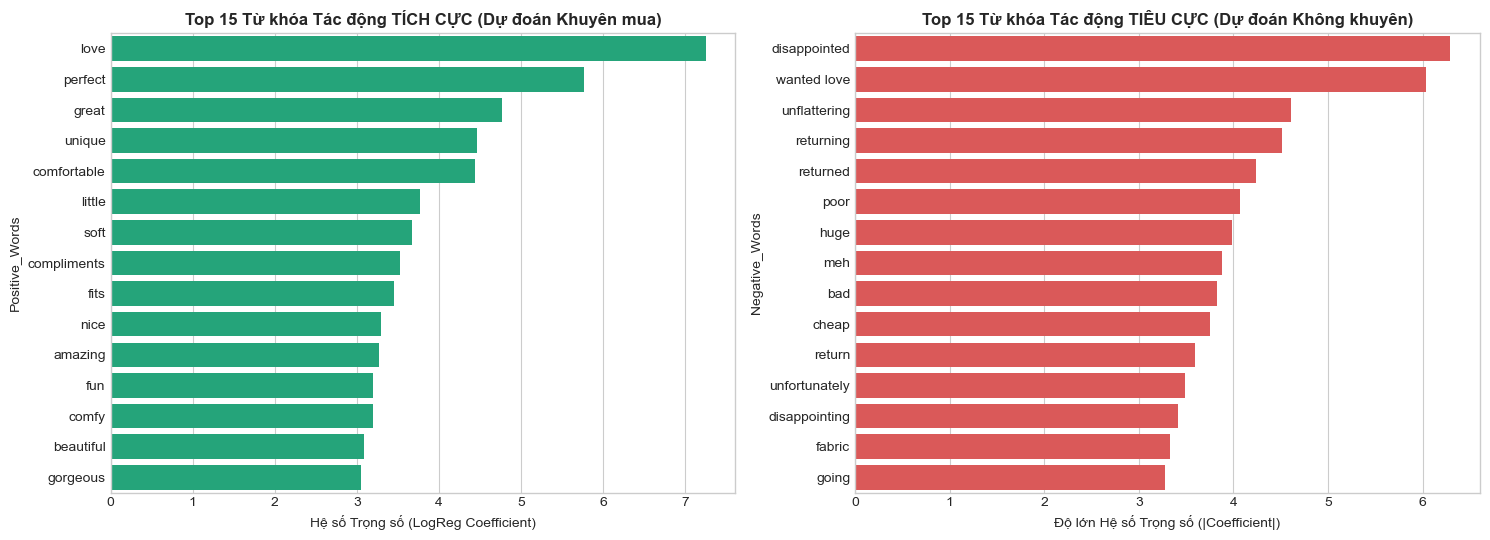

In [8]:
feature_names = np.array(tfidf_vec.get_feature_names_out())
coefs = best_model.coef_[0]

# Top 15 từ khóa tác động tích cực (khiến mô hình dự đoán KHUYÊN MUA)
top_pos_idx = np.argsort(coefs)[-15:][::-1]
# Top 15 từ khóa tác động tiêu cực (khiến mô hình dự đoán KHÔNG KHUYÊN MUA)
top_neg_idx = np.argsort(coefs)[:15]

df_top_features = pd.DataFrame({
    'Positive_Words': feature_names[top_pos_idx],
    'Pos_Weight': coefs[top_pos_idx],
    'Negative_Words': feature_names[top_neg_idx],
    'Neg_Weight': coefs[top_neg_idx]
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x='Pos_Weight', y='Positive_Words', data=df_top_features, ax=axes[0], color='#10b981')
axes[0].set_title('Top 15 Từ khóa Tác động TÍCH CỰC (Dự đoán Khuyên mua)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hệ số Trọng số (LogReg Coefficient)')

sns.barplot(x=df_top_features['Neg_Weight'].abs(), y='Negative_Words', data=df_top_features, ax=axes[1], color='#ef4444')
axes[1].set_title('Top 15 Từ khóa Tác động TIÊU CỰC (Dự đoán Không khuyên)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Độ lớn Hệ số Trọng số (|Coefficient|)')

plt.tight_layout()
plt.show()

Phân tích hệ số của Logistic Regression cho thấy ba pattern nổi bật. Thứ nhất, hành vi không khuyến nghị có liên hệ mạnh với các review đề cập đến việc trả hàng, thể hiện qua các từ return, returned, returning. Thứ hai, độ vừa vặn và ngoại hình sản phẩm là yếu tố phân cực rõ rệt: các từ fits, perfect, comfortable liên quan đến khuyến nghị, trong khi unflattering và huge liên quan đến không khuyến nghị. Thứ ba, cảm nhận về chất liệu và chất lượng cũng đóng vai trò quan trọng, với soft xuất hiện ở nhóm tích cực còn poor, cheap, fabric xuất hiện ở nhóm tiêu cực. Ngoài ra, bigram wanted love cho thấy mô hình có thể phát hiện cả những ngữ cảnh thất vọng mà từng từ riêng lẻ không thể hiện rõ.

## 11. Business Interpretation

Kết quả phân tích cho thấy hành vi khuyến nghị sản phẩm không diễn ra ngẫu nhiên mà gắn với một số pattern rõ ràng trong trải nghiệm của khách hàng.

Thứ nhất, **mức độ hài lòng thể hiện qua Rating có liên hệ rất mạnh với hành vi khuyến nghị**. Các review có Rating 4–5 gần như luôn đi kèm `Recommended IND = 1`, trong khi Rating 1–2 hầu như không khuyến nghị sản phẩm. Điều này cho thấy hành vi recommend là một tín hiệu trực tiếp phản ánh mức độ hài lòng của khách hàng.

Thứ hai, **độ vừa vặn và hình thức sản phẩm là một yếu tố phân cực rõ rệt**. Các từ như `fits`, `perfect`, `comfortable` thường liên quan đến các review khuyến nghị, trong khi `unflattering` và `huge` thường xuất hiện trong các review không khuyến nghị. Điều này cho thấy vấn đề về fit, kích thước và hình dáng sản phẩm có ảnh hưởng đáng kể đến trải nghiệm khách hàng.

Thứ ba, **cảm nhận về chất liệu và chất lượng sản phẩm cũng là một yếu tố quan trọng**. Các từ như `soft` xuất hiện ở nhóm tích cực, trong khi `poor`, `cheap`, `fabric` xuất hiện nhiều hơn ở nhóm tiêu cực. Điều này cho thấy khách hàng không chỉ quan tâm đến kiểu dáng mà còn phản ứng mạnh với chất lượng cảm nhận của sản phẩm.

Thứ tư, **hành vi không khuyến nghị có liên hệ rõ với ý định trả hàng**. Các từ `return`, `returned`, `returning` đều nằm trong nhóm từ có ảnh hưởng tiêu cực mạnh. Đây là một dấu hiệu cho thấy review tiêu cực có thể được sử dụng như một tín hiệu sớm để phát hiện nguy cơ khách hàng trả lại sản phẩm.

Ngoài ra, một số bigram như `wanted love` cho thấy ngữ cảnh của cụm từ quan trọng hơn từng từ riêng lẻ. Cụm này thường xuất hiện trong các review thể hiện sự thất vọng, dù từng từ `wanted` và `love` không mang nghĩa tiêu cực khi đứng riêng.

Mô hình được xây dựng có khả năng dự đoán `Recommended IND` từ nội dung `Title` và `Review Text`. Trong thực tế, doanh nghiệp e-commerce có thể sử dụng kết quả này để:

- phát hiện sớm các review có dấu hiệu không hài lòng;
- xác định các vấn đề phổ biến liên quan đến size, fit, chất liệu hoặc chất lượng sản phẩm;
- ưu tiên chăm sóc các khách hàng có nguy cơ trả hàng hoặc không tiếp tục mua;
- cải thiện mô tả sản phẩm, hướng dẫn chọn size và thông tin về chất liệu;
- nhận diện các đặc điểm được khách hàng đánh giá cao để sử dụng trong hoạt động marketing;
- hỗ trợ đề xuất các sản phẩm tương tự cho những khách hàng có trải nghiệm tích cực.

Như vậy, giá trị chính của mô hình không chỉ nằm ở việc dự đoán khách hàng có khuyến nghị sản phẩm hay không, mà còn ở khả năng **phát hiện những yếu tố cụ thể đứng sau sự hài lòng và không hài lòng của khách hàng**, từ đó hỗ trợ doanh nghiệp cải thiện sản phẩm và trải nghiệm mua sắm.

## 12. Lưu TF-IDF vectorizer và model để deploy

Cell này lưu vectorizer đã fit trên train và sáu model đã train dưới dạng SAV. REST API phải load đúng TF-IDF vectorizer trước, sau đó mới đưa vector số vào model.

In [9]:
import pickle
from pathlib import Path

MODEL_DIR = Path(r"C:\Users\ASUS\Code\Assigned_2\customer_behavior\model")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

with open(MODEL_DIR / "tfidf_vectorizer.sav", "wb") as file:
    pickle.dump(tfidf_vec, file)

models_to_save = {
    "logistic_regression": models["Logistic Regression (Balanced)"],
    "linear_svm": models["Linear SVM (Balanced)"],
    "multinomial_naive_bayes": models["Multinomial Naive Bayes"],
    "sgd_classifier": models["SGD Classifier (Balanced Log)"],
    "decision_tree": models["Decision Tree"],
    "random_forest": models["Random Forest (Balanced)"],
}

for name, model in models_to_save.items():
    with open(MODEL_DIR / f"{name}.sav", "wb") as file:
        pickle.dump(model, file)

print(f"Đã lưu TF-IDF vectorizer và {len(models_to_save)} model vào: {MODEL_DIR}")

Đã lưu TF-IDF vectorizer và 6 model vào: C:\Users\ASUS\Code\Assigned_2\customer_behavior\model
